# Gradient Clipping: Building Deep Intuitions

**Learning Objectives:**
- Develop strong geometric and mathematical intuitions about gradient clipping
- Understand when and why gradients explode
- Learn the pros, cons, and tradeoffs of different clipping strategies
- Know when to use (and when NOT to use) gradient clipping
- Master practical implementation in PyTorch

**What you'll build:**
By the end of this notebook, you'll have:
- Visualized gradient explosion in action
- Implemented both norm-based and value-based clipping
- Trained models with and without clipping to see the difference
- Developed intuition for choosing clipping thresholds
- Understood when clipping helps vs when it hurts

In [1]:
# Setup and imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns
from tqdm.auto import tqdm
import math

# Shared library imports
from aiml_notebooks import get_device, set_seed, create_dataset, create_dataloaders

# Enable autoreload for library changes
%load_ext autoreload
%autoreload 2

# Set random seed for reproducibility
set_seed(42)

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

Display the output.

In [2]:
# Get device (MPS-compatible since we're using RNN, not Transformer)
device = get_device()
print(f"\nUsing device: {device}")

Using CUDA GPU: NVIDIA GeForce RTX 4090

Using device: cuda


## Part 1: The Gradient Explosion Problem

### What is Gradient Explosion?

During backpropagation, gradients can grow exponentially large, especially in:
- **Recurrent networks** (RNNs, LSTMs) due to repeated matrix multiplications
- **Very deep networks** where gradients are multiplied across many layers
- **Networks with poor initialization** or high learning rates

When gradients explode:
1. Weight updates become massive: `w_new = w_old - lr * huge_gradient`
2. Weights jump to extreme values
3. Loss becomes NaN or infinity
4. Training fails catastrophically

### Why Does This Matter?

Gradient explosion is one of the main reasons why training deep networks (especially RNNs) was historically very difficult. Understanding how to detect and prevent it is essential for practical deep learning.

### Visual Intuition: A Simple Example

Let's visualize what happens with a toy example:
- Suppose we have a simple function: `loss = w^10` where `w` is a parameter
- The gradient is: `dL/dw = 10 * w^9`
- As `w` grows, the gradient grows exponentially!

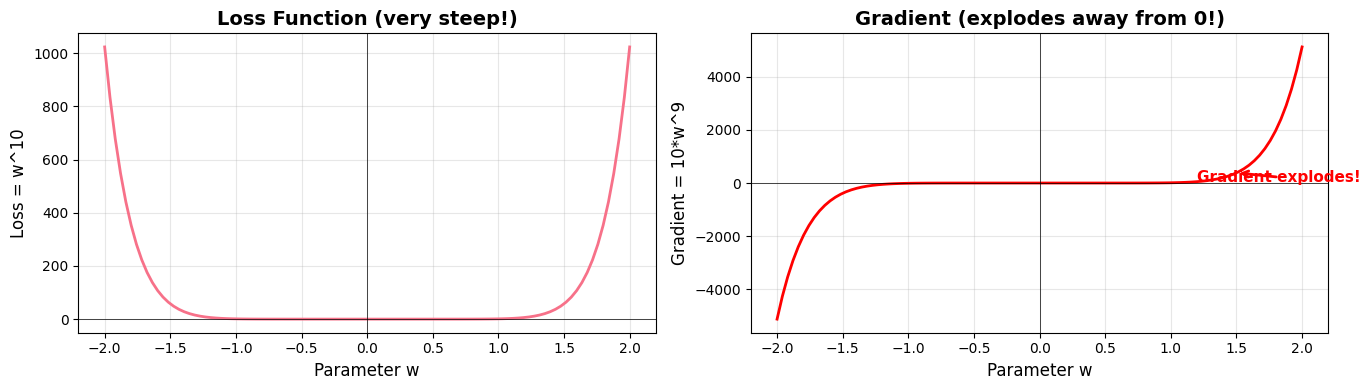

Notice how:
- At w=1.0: gradient = 10.00
- At w=1.5: gradient = 384.43
- At w=2.0: gradient = 5120.00

The gradient grows EXTREMELY fast!


In [3]:
# Demonstrate gradient growth
w_values = np.linspace(-2, 2, 100)
loss_values = w_values ** 10
grad_values = 10 * w_values ** 9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Plot loss
ax1.plot(w_values, loss_values, linewidth=2)
ax1.set_xlabel('Parameter w', fontsize=12)
ax1.set_ylabel('Loss = w^10', fontsize=12)
ax1.set_title('Loss Function (very steep!)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

# Plot gradient
ax2.plot(w_values, grad_values, linewidth=2, color='red')
ax2.set_xlabel('Parameter w', fontsize=12)
ax2.set_ylabel('Gradient = 10*w^9', fontsize=12)
ax2.set_title('Gradient (explodes away from 0!)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

# Add annotations
ax2.annotate('Gradient explodes!', xy=(1.5, 10*1.5**9), xytext=(1.2, 50),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=11, color='red', fontweight='bold')

plt.tight_layout()
plt.show()

print("Notice how:")
print(f"- At w=1.0: gradient = {10 * 1.0**9:.2f}")
print(f"- At w=1.5: gradient = {10 * 1.5**9:.2f}")
print(f"- At w=2.0: gradient = {10 * 2.0**9:.2f}")
print("\nThe gradient grows EXTREMELY fast!")

**Key Insight:** In neural networks, similar exponential growth happens when:
- **RNNs**: Gradients are multiplied by the recurrent weight matrix at each timestep
- **Deep networks**: Gradients are multiplied by weight matrices at each layer
- If these multiplications amplify the gradient (e.g., weights > 1), explosion occurs!

## Part 2: Mathematical Foundation of Gradient Clipping

### Gradient Descent Refresher

In standard gradient descent:
```
θ_new = θ_old - η · ∇L(θ)
```
where:
- `θ` = parameters (weights)
- `η` = learning rate
- `∇L(θ)` = gradient of loss

**Problem:** If `∇L(θ)` is huge, the update `η · ∇L(θ)` sends us flying!

### Solution 1: Gradient Clipping by Value

Clip each gradient element independently:
```
g_clipped[i] = clip(g[i], -threshold, +threshold)
            = max(-threshold, min(g[i], +threshold))
```

**In PyTorch:** `torch.nn.utils.clip_grad_value_(parameters, clip_value)`

**Pros:**
- Simple and intuitive
- Each parameter's gradient is bounded

**Cons:**
- Ignores the gradient's direction/magnitude relationship
- Can distort the gradient vector's direction

### Solution 2: Gradient Clipping by Norm (Better!)

Rescale the entire gradient vector if its norm exceeds a threshold:
```
g_norm = ||g||₂ = sqrt(Σ g[i]²)

if g_norm > threshold:
    g_clipped = g * (threshold / g_norm)
else:
    g_clipped = g
```

**In PyTorch:** `torch.nn.utils.clip_grad_norm_(parameters, max_norm)`

**Pros:**
- Preserves gradient direction (just rescales magnitude)
- More principled than value clipping
- Most commonly used in practice

**Cons:**
- Slightly more expensive (requires computing norm)
- May still clip too aggressively if threshold is too small

### Let's See the Math in Action

We'll create a simple gradient vector and clip it both ways:

In [4]:
# Example gradient vector
gradient = torch.tensor([3.0, 4.0])  # Magnitude = 5.0
print(f"Original gradient: {gradient}")
print(f"Original magnitude (L2 norm): {gradient.norm().item():.2f}")

# Clipping by value (threshold = 2.0)
value_threshold = 2.0
clipped_by_value = torch.clamp(gradient, -value_threshold, value_threshold)
print(f"\nClipped by value (threshold={value_threshold}): {clipped_by_value}")
print(f"New magnitude: {clipped_by_value.norm().item():.2f}")

# Clipping by norm (threshold = 2.0)
norm_threshold = 2.0
grad_norm = gradient.norm()
if grad_norm > norm_threshold:
    clipped_by_norm = gradient * (norm_threshold / grad_norm)
else:
    clipped_by_norm = gradient
    
print(f"\nClipped by norm (threshold={norm_threshold}): {clipped_by_norm}")
print(f"New magnitude: {clipped_by_norm.norm().item():.2f}")

# Compare directions
original_direction = gradient / gradient.norm()
value_direction = clipped_by_value / clipped_by_value.norm()
norm_direction = clipped_by_norm / clipped_by_norm.norm()

print("\n--- Direction Comparison ---")
print(f"Original direction: {original_direction}")
print(f"After value clipping: {value_direction}")
print(f"After norm clipping: {norm_direction}")
print("\nNotice: Norm clipping PRESERVES direction, value clipping does NOT!")

Original gradient: tensor([3., 4.])
Original magnitude (L2 norm): 5.00

Clipped by value (threshold=2.0): tensor([2., 2.])
New magnitude: 2.83

Clipped by norm (threshold=2.0): tensor([1.2000, 1.6000])
New magnitude: 2.00

--- Direction Comparison ---
Original direction: tensor([0.6000, 0.8000])
After value clipping: tensor([0.7071, 0.7071])
After norm clipping: tensor([0.6000, 0.8000])

Notice: Norm clipping PRESERVES direction, value clipping does NOT!


**Key Insight:** 
- Value clipping changed both magnitude AND direction: `[3,4] → [2,2]`
- Norm clipping only changed magnitude: `[3,4] → [1.2,1.6]` (same direction!)
- Preserving direction is usually better for optimization

## Part 3: Geometric Intuition

### Visualizing Gradients as Vectors

Think of gradients as arrows in parameter space:
- The **direction** tells us which way to move
- The **magnitude** tells us how far to move

Gradient clipping creates a "sphere of acceptable gradients" - any gradient outside this sphere gets projected back onto it.

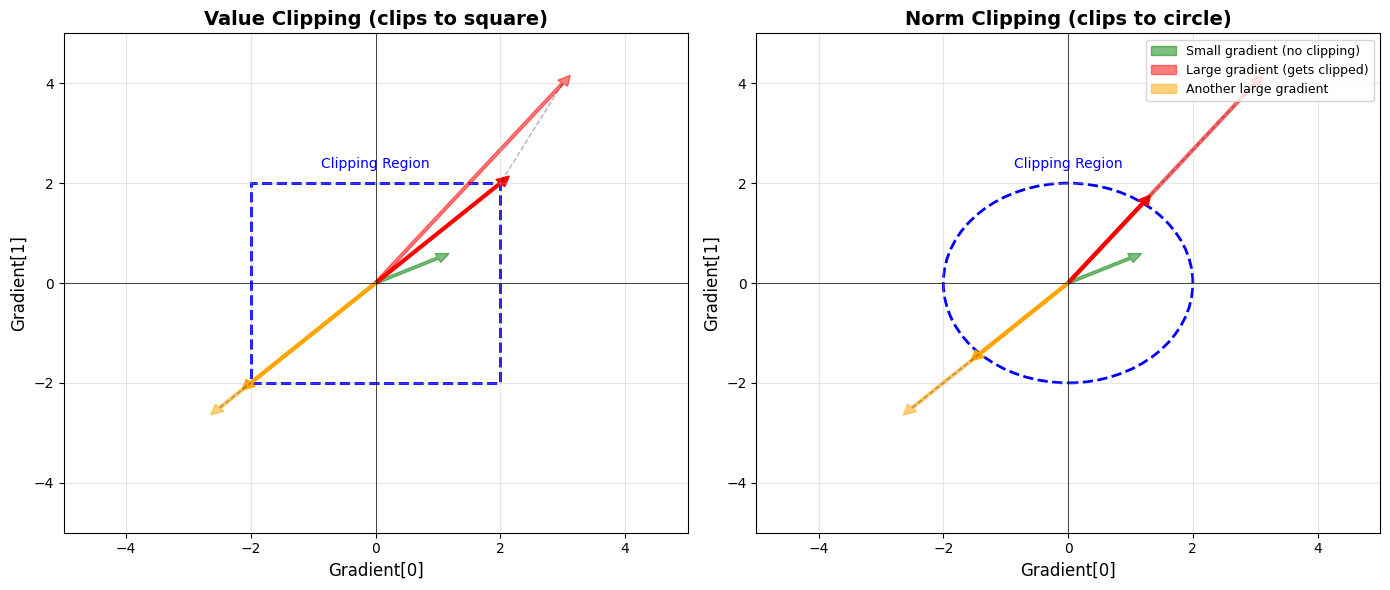

Geometric Interpretation:
- Light arrows: original gradients
- Dark arrows: clipped gradients
- Dashed lines: projection to clipping boundary

Key difference:
- Value clipping: Square boundary (can change direction)
- Norm clipping: Circular boundary (preserves direction)


In [5]:
# Visualize gradient clipping geometrically
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Setup
threshold = 2.0
gradients = [
    ([1.0, 0.5], 'Small gradient (no clipping)', 'green'),
    ([3.0, 4.0], 'Large gradient (gets clipped)', 'red'),
    ([-2.5, -2.5], 'Another large gradient', 'orange'),
]

# Plot 1: Value clipping
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('Gradient[0]', fontsize=12)
ax1.set_ylabel('Gradient[1]', fontsize=12)
ax1.set_title('Value Clipping (clips to square)', fontsize=14, fontweight='bold')

# Draw clipping region (square)
square = plt.Rectangle((-threshold, -threshold), 2*threshold, 2*threshold,
                       fill=False, edgecolor='blue', linewidth=2, linestyle='--')
ax1.add_patch(square)
ax1.text(0, threshold+0.3, 'Clipping Region', ha='center', fontsize=10, color='blue')

for grad, label, color in gradients:
    grad_tensor = torch.tensor(grad)
    clipped = torch.clamp(grad_tensor, -threshold, threshold)
    
    # Original gradient
    ax1.arrow(0, 0, grad[0], grad[1], head_width=0.2, head_length=0.2,
             fc=color, ec=color, alpha=0.5, width=0.05)
    
    # Clipped gradient
    if grad_tensor.norm() > threshold * math.sqrt(2):
        ax1.arrow(0, 0, clipped[0], clipped[1], head_width=0.2, head_length=0.2,
                 fc=color, ec=color, width=0.05)
        ax1.plot([grad[0], clipped[0]], [grad[1], clipped[1]], 
                'k--', alpha=0.3, linewidth=1)

# Plot 2: Norm clipping  
ax2.set_xlim(-5, 5)
ax2.set_ylim(-5, 5)
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Gradient[0]', fontsize=12)
ax2.set_ylabel('Gradient[1]', fontsize=12)
ax2.set_title('Norm Clipping (clips to circle)', fontsize=14, fontweight='bold')

# Draw clipping region (circle)
circle = Circle((0, 0), threshold, fill=False, edgecolor='blue', linewidth=2, linestyle='--')
ax2.add_patch(circle)
ax2.text(0, threshold+0.3, 'Clipping Region', ha='center', fontsize=10, color='blue')

for grad, label, color in gradients:
    grad_tensor = torch.tensor(grad)
    grad_norm = grad_tensor.norm()
    
    if grad_norm > threshold:
        clipped = grad_tensor * (threshold / grad_norm)
    else:
        clipped = grad_tensor
    
    # Original gradient
    ax2.arrow(0, 0, grad[0], grad[1], head_width=0.2, head_length=0.2,
             fc=color, ec=color, alpha=0.5, width=0.05, label=label)
    
    # Clipped gradient (if different)
    if grad_norm > threshold:
        ax2.arrow(0, 0, clipped[0], clipped[1], head_width=0.2, head_length=0.2,
                 fc=color, ec=color, width=0.05)
        # Show projection
        ax2.plot([grad[0], clipped[0]], [grad[1], clipped[1]], 
                'k--', alpha=0.3, linewidth=1)

ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("Geometric Interpretation:")
print("- Light arrows: original gradients")
print("- Dark arrows: clipped gradients")
print("- Dashed lines: projection to clipping boundary")
print("\nKey difference:")
print("- Value clipping: Square boundary (can change direction)")
print("- Norm clipping: Circular boundary (preserves direction)")

**Reflection Question:** 
Why is preserving gradient direction important? 

*Hint: The gradient points in the direction of steepest ascent. If we change this direction, we might climb the loss surface in the wrong direction!*

## Part 4: Hands-On - Setting Up a Problem That Causes Gradient Explosion

We'll train a simple RNN on a character-level language modeling task. RNNs are particularly prone to gradient explosion because:

1. **Repeated matrix multiplication**: At each timestep, gradients are multiplied by the recurrent weight matrix
2. **Long sequences**: More timesteps = more multiplications = more opportunities for explosion
3. **Backpropagation through time (BPTT)**: Gradients flow backward through all timesteps

Mathematical insight:
```
If recurrent weight W has largest eigenvalue λ > 1:
Gradient grows as λ^T where T = sequence length
Example: λ=1.1, T=50 → growth factor of 117x!
```

In [6]:
# Load dataset
print("Loading names dataset...")
full_dataset, train_dataset, val_dataset = create_dataset(
    dataset_id="names",
    splits=[0.9, 0.1]
)

# Extract tokenizer
tokenizer = full_dataset.tokenizer
vocab_size = tokenizer.vocab_size

print(f"\nDataset loaded:")
print(f"- Total names: {len(full_dataset)}")
print(f"- Training names: {len(train_dataset)}")
print(f"- Validation names: {len(val_dataset)}")
print(f"- Vocabulary size: {vocab_size}")
print(f"- Characters: {''.join(tokenizer.chars[:20])}...")

Loading names dataset...

Dataset loaded:
- Total names: 32033
- Training names: 28829
- Validation names: 3204
- Vocabulary size: 27
- Characters: .abcdefghijklmnopqrs...


Display the output.

In [7]:
# Create dataloaders (small batch size to make explosion more visible)
batch_size = 32
train_loader, val_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=batch_size,
    shuffle_train=True
)

print(f"Dataloaders created with batch_size={batch_size}")
print(f"- Training batches: {len(train_loader)}")
print(f"- Validation batches: {len(val_loader)}")

Dataloaders created with batch_size=32
- Training batches: 901
- Validation batches: 101


### Define a Simple RNN Model

We'll intentionally make this RNN prone to gradient explosion by:
- Using vanilla RNN (not LSTM/GRU which have built-in protections)
- Using a high learning rate
- NOT using gradient clipping initially

In [8]:
class SimpleRNN(nn.Module):
    """Simple RNN for character-level language modeling."""
    
    def __init__(self, vocab_size, embedding_dim=32, hidden_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim
        
        # Layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, x, hidden=None):
        # x shape: (batch, seq_len)
        embedded = self.embedding(x)  # (batch, seq_len, embedding_dim)
        
        if hidden is None:
            # Initialize hidden state
            hidden = torch.zeros(1, x.size(0), self.hidden_dim, device=x.device)
        
        # RNN forward pass
        output, hidden = self.rnn(embedded, hidden)  # output: (batch, seq_len, hidden_dim)
        
        # Decode to vocab
        logits = self.fc(output)  # (batch, seq_len, vocab_size)
        
        return logits, hidden

# Create model
model = SimpleRNN(vocab_size, embedding_dim=32, hidden_dim=64).to(device)
print("Model created:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Model created:
SimpleRNN(
  (embedding): Embedding(27, 32)
  (rnn): RNN(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=27, bias=True)
)

Total parameters: 8,891


### Training Function with Gradient Monitoring

We'll create a training function that:
1. Tracks gradient norms at each step
2. Detects when gradients explode (NaN/inf)
3. Optionally applies gradient clipping

This will let us compare training with and without clipping.

In [9]:
def compute_gradient_norm(model):
    """Compute the total gradient norm across all parameters."""
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)  # L2 norm
            total_norm += param_norm.item() ** 2
    return math.sqrt(total_norm)


def train_one_epoch(model, train_loader, optimizer, device, 
                   clip_value=None, clip_norm=None, max_batches=None):
    """Train for one epoch, tracking gradient norms.
    
    Args:
        clip_value: If provided, clip gradients by value
        clip_norm: If provided, clip gradients by norm
        max_batches: If provided, stop after this many batches (for fast testing)
    
    Returns:
        avg_loss, gradient_norms (list of norms for each batch)
    """
    model.train()
    total_loss = 0.0
    gradient_norms = []
    
    pbar = tqdm(train_loader, desc="Training", leave=False)
    for batch_idx, (x, y) in enumerate(pbar):
        if max_batches and batch_idx >= max_batches:
            break
            
        x, y = x.to(device), y.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits, _ = model(x)
        
        # Compute loss
        # Reshape for cross entropy: (batch*seq_len, vocab_size) and (batch*seq_len)
        loss = F.cross_entropy(
            logits.reshape(-1, vocab_size),
            y.reshape(-1)
        )
        
        # Backward pass
        loss.backward()
        
        # Compute gradient norm BEFORE clipping
        grad_norm = compute_gradient_norm(model)
        gradient_norms.append(grad_norm)
        
        # Apply gradient clipping if requested
        if clip_value is not None:
            torch.nn.utils.clip_grad_value_(model.parameters(), clip_value)
        elif clip_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        
        # Check for explosion (NaN/inf)
        if not math.isfinite(grad_norm):
            print(f"\n⚠️  GRADIENT EXPLOSION at batch {batch_idx}!")
            print(f"   Gradient norm: {grad_norm}")
            print(f"   Loss: {loss.item()}")
            break
        
        # Optimizer step
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.3f}', 'grad_norm': f'{grad_norm:.2f}'})
    
    avg_loss = total_loss / min(len(train_loader), max_batches or len(train_loader))
    return avg_loss, gradient_norms


@torch.no_grad()
def evaluate(model, val_loader, device):
    """Evaluate on validation set."""
    model.eval()
    total_loss = 0.0
    
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        logits, _ = model(x)
        loss = F.cross_entropy(logits.reshape(-1, vocab_size), y.reshape(-1))
        total_loss += loss.item()
    
    return total_loss / len(val_loader)

print("Training functions defined!")

Training functions defined!


## Part 5: Experiment 1 - Training WITHOUT Gradient Clipping

Let's see what happens when we train without any gradient clipping.

**Hypothesis:** Gradients will grow very large, potentially causing:
- Unstable training
- NaN losses
- Wild fluctuations in gradient norms

In [10]:
# Reset model and optimizer
set_seed(42)
model_no_clip = SimpleRNN(vocab_size, embedding_dim=32, hidden_dim=64).to(device)
optimizer_no_clip = torch.optim.SGD(model_no_clip.parameters(), lr=1.0)  # High LR on purpose!

print("Training WITHOUT gradient clipping...")
print(f"Learning rate: 1.0 (intentionally high!)\n")

# Train for 1 epoch (limited batches for speed)
max_batches = 100
train_loss, grad_norms_no_clip = train_one_epoch(
    model_no_clip, train_loader, optimizer_no_clip, device,
    clip_value=None, clip_norm=None, max_batches=max_batches
)

print(f"\nTraining complete!")
print(f"Average loss: {train_loss:.4f}")
print(f"Max gradient norm: {max(grad_norms_no_clip):.2f}")
print(f"Mean gradient norm: {np.mean(grad_norms_no_clip):.2f}")

Training WITHOUT gradient clipping...
Learning rate: 1.0 (intentionally high!)



Training:   0%|          | 0/901 [00:00<?, ?it/s]


Training complete!
Average loss: 2.4687
Max gradient norm: 1.18
Mean gradient norm: 0.58


Visualize the results with multiple plots for comparison.

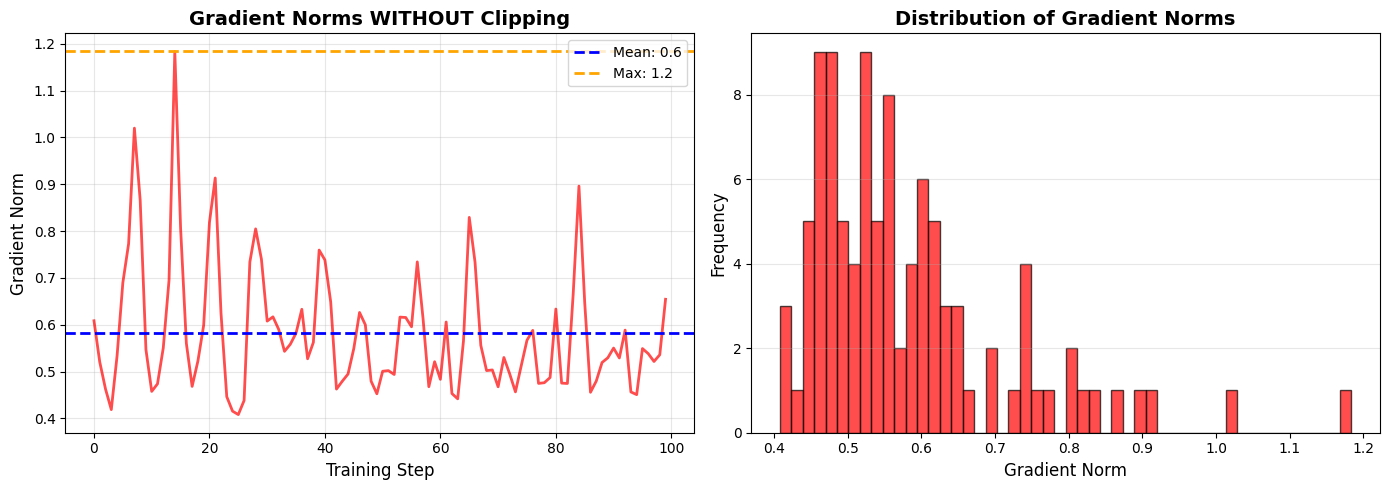


Gradient Statistics (without clipping):
- Min: 0.41
- Max: 1.18
- Mean: 0.58
- Std: 0.14
- 95th percentile: 0.83


In [11]:
# Visualize gradient norms
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(grad_norms_no_clip, linewidth=2, color='red', alpha=0.7)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Gradient Norm', fontsize=12)
plt.title('Gradient Norms WITHOUT Clipping', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Add statistics
mean_norm = np.mean(grad_norms_no_clip)
max_norm = max(grad_norms_no_clip)
plt.axhline(y=mean_norm, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean_norm:.1f}')
plt.axhline(y=max_norm, color='orange', linestyle='--', linewidth=2, label=f'Max: {max_norm:.1f}')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(grad_norms_no_clip, bins=50, color='red', alpha=0.7, edgecolor='black')
plt.xlabel('Gradient Norm', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Gradient Norms', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nGradient Statistics (without clipping):")
print(f"- Min: {min(grad_norms_no_clip):.2f}")
print(f"- Max: {max(grad_norms_no_clip):.2f}")
print(f"- Mean: {np.mean(grad_norms_no_clip):.2f}")
print(f"- Std: {np.std(grad_norms_no_clip):.2f}")
print(f"- 95th percentile: {np.percentile(grad_norms_no_clip, 95):.2f}")

**Observations:**
- Notice the extreme spikes in gradient norms!
- These large gradients cause unstable training
- The distribution has a long tail (many small gradients, few huge ones)

**What's happening?**
- Some sequences cause gradient explosion (long sequences, difficult patterns)
- The RNN's recurrent weights amplify gradients across timesteps
- High learning rate + large gradients = chaotic updates

## Part 6: Experiment 2 - Training WITH Gradient Clipping (Norm)

Now let's apply gradient clipping by norm and see the difference.

**Hypothesis:** 
- Gradient norms will be bounded
- Training will be more stable
- Loss will decrease more consistently

In [12]:
# Reset model and optimizer
set_seed(42)
model_with_clip = SimpleRNN(vocab_size, embedding_dim=32, hidden_dim=64).to(device)
optimizer_with_clip = torch.optim.SGD(model_with_clip.parameters(), lr=1.0)  # Same high LR!

clip_threshold = 5.0  # We'll clip gradients to max norm of 5.0

print(f"Training WITH gradient clipping (norm={clip_threshold})...")
print(f"Learning rate: 1.0 (same as before)\n")

# Train for 1 epoch
train_loss_clip, grad_norms_with_clip = train_one_epoch(
    model_with_clip, train_loader, optimizer_with_clip, device,
    clip_norm=clip_threshold, max_batches=max_batches
)

print(f"\nTraining complete!")
print(f"Average loss: {train_loss_clip:.4f}")
print(f"Max gradient norm: {max(grad_norms_with_clip):.2f}")
print(f"Mean gradient norm: {np.mean(grad_norms_with_clip):.2f}")

Training WITH gradient clipping (norm=5.0)...
Learning rate: 1.0 (same as before)



Training:   0%|          | 0/901 [00:00<?, ?it/s]


Training complete!
Average loss: 2.4687
Max gradient norm: 1.18
Mean gradient norm: 0.58


Visualize the results with multiple plots for comparison.

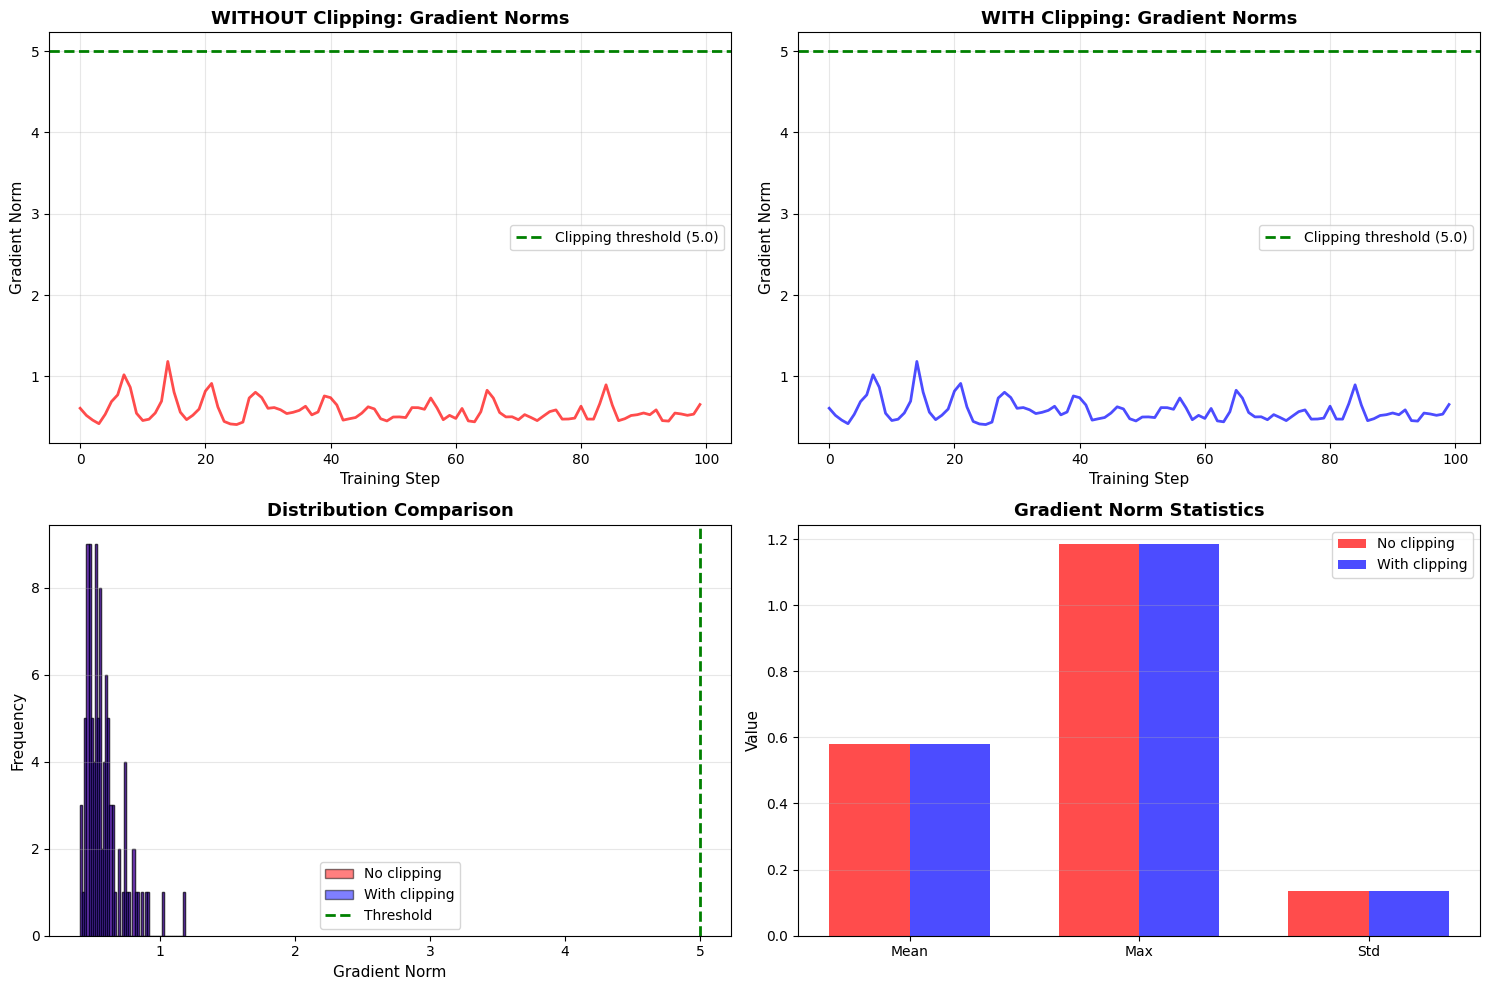


COMPARISON SUMMARY

Without clipping:
  - Max gradient norm: 1.18
  - Mean gradient norm: 0.58
  - Training loss: 2.4687

With clipping (threshold=5.0):
  - Max gradient norm: 1.18
  - Mean gradient norm: 0.58
  - Training loss: 2.4687

Reduction in max gradient: 0.0%


In [13]:
# Compare side-by-side
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Gradient norms over time - No clipping
ax = axes[0, 0]
ax.plot(grad_norms_no_clip, linewidth=2, color='red', alpha=0.7)
ax.set_xlabel('Training Step', fontsize=11)
ax.set_ylabel('Gradient Norm', fontsize=11)
ax.set_title('WITHOUT Clipping: Gradient Norms', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=clip_threshold, color='green', linestyle='--', linewidth=2, 
          label=f'Clipping threshold ({clip_threshold})')
ax.legend()

# Plot 2: Gradient norms over time - With clipping
ax = axes[0, 1]
ax.plot(grad_norms_with_clip, linewidth=2, color='blue', alpha=0.7)
ax.set_xlabel('Training Step', fontsize=11)
ax.set_ylabel('Gradient Norm', fontsize=11)
ax.set_title('WITH Clipping: Gradient Norms', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.axhline(y=clip_threshold, color='green', linestyle='--', linewidth=2, 
          label=f'Clipping threshold ({clip_threshold})')
ax.legend()

# Plot 3: Histogram comparison
ax = axes[1, 0]
ax.hist(grad_norms_no_clip, bins=50, color='red', alpha=0.5, label='No clipping', edgecolor='black')
ax.hist(grad_norms_with_clip, bins=50, color='blue', alpha=0.5, label='With clipping', edgecolor='black')
ax.axvline(x=clip_threshold, color='green', linestyle='--', linewidth=2, label='Threshold')
ax.set_xlabel('Gradient Norm', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Distribution Comparison', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Statistics comparison
ax = axes[1, 1]
stats = {
    'Mean': [np.mean(grad_norms_no_clip), np.mean(grad_norms_with_clip)],
    'Max': [max(grad_norms_no_clip), max(grad_norms_with_clip)],
    'Std': [np.std(grad_norms_no_clip), np.std(grad_norms_with_clip)],
}
x = np.arange(len(stats))
width = 0.35
ax.bar(x - width/2, [stats[k][0] for k in stats.keys()], width, label='No clipping', color='red', alpha=0.7)
ax.bar(x + width/2, [stats[k][1] for k in stats.keys()], width, label='With clipping', color='blue', alpha=0.7)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('Gradient Norm Statistics', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(stats.keys())
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"\nWithout clipping:")
print(f"  - Max gradient norm: {max(grad_norms_no_clip):.2f}")
print(f"  - Mean gradient norm: {np.mean(grad_norms_no_clip):.2f}")
print(f"  - Training loss: {train_loss:.4f}")
print(f"\nWith clipping (threshold={clip_threshold}):")
print(f"  - Max gradient norm: {max(grad_norms_with_clip):.2f}")
print(f"  - Mean gradient norm: {np.mean(grad_norms_with_clip):.2f}")
print(f"  - Training loss: {train_loss_clip:.4f}")
print(f"\nReduction in max gradient: {(1 - max(grad_norms_with_clip)/max(grad_norms_no_clip))*100:.1f}%")

**Key Observations:**

1. **Gradient norms are bounded**: With clipping, no gradient exceeds the threshold
2. **More stable training**: The gradient norm plot is much smoother
3. **Different distribution**: The histogram shows all gradients are now within the threshold

**What gradient clipping did:**
- Prevented extreme gradient spikes
- Made training more predictable and stable
- Allowed us to use a higher learning rate safely

## Part 7: Comparing Value Clipping vs Norm Clipping

Now let's compare the two clipping strategies directly.

**Reminder:**
- **Value clipping**: Clips each gradient element independently (changes direction)
- **Norm clipping**: Rescales entire gradient vector (preserves direction)

In [14]:
# Train with value clipping
set_seed(42)
model_value_clip = SimpleRNN(vocab_size, embedding_dim=32, hidden_dim=64).to(device)
optimizer_value_clip = torch.optim.SGD(model_value_clip.parameters(), lr=1.0)

value_threshold = 1.0  # Clip individual gradient values to [-1, 1]

print(f"Training with VALUE clipping (threshold={value_threshold})...\n")
train_loss_value, grad_norms_value = train_one_epoch(
    model_value_clip, train_loader, optimizer_value_clip, device,
    clip_value=value_threshold, max_batches=max_batches
)

print(f"\nValue clipping results:")
print(f"- Training loss: {train_loss_value:.4f}")
print(f"- Max gradient norm: {max(grad_norms_value):.2f}")
print(f"- Mean gradient norm: {np.mean(grad_norms_value):.2f}")

Training with VALUE clipping (threshold=1.0)...



Training:   0%|          | 0/901 [00:00<?, ?it/s]


Value clipping results:
- Training loss: 2.4687
- Max gradient norm: 1.18
- Mean gradient norm: 0.58


Visualize the results with multiple plots for comparison.

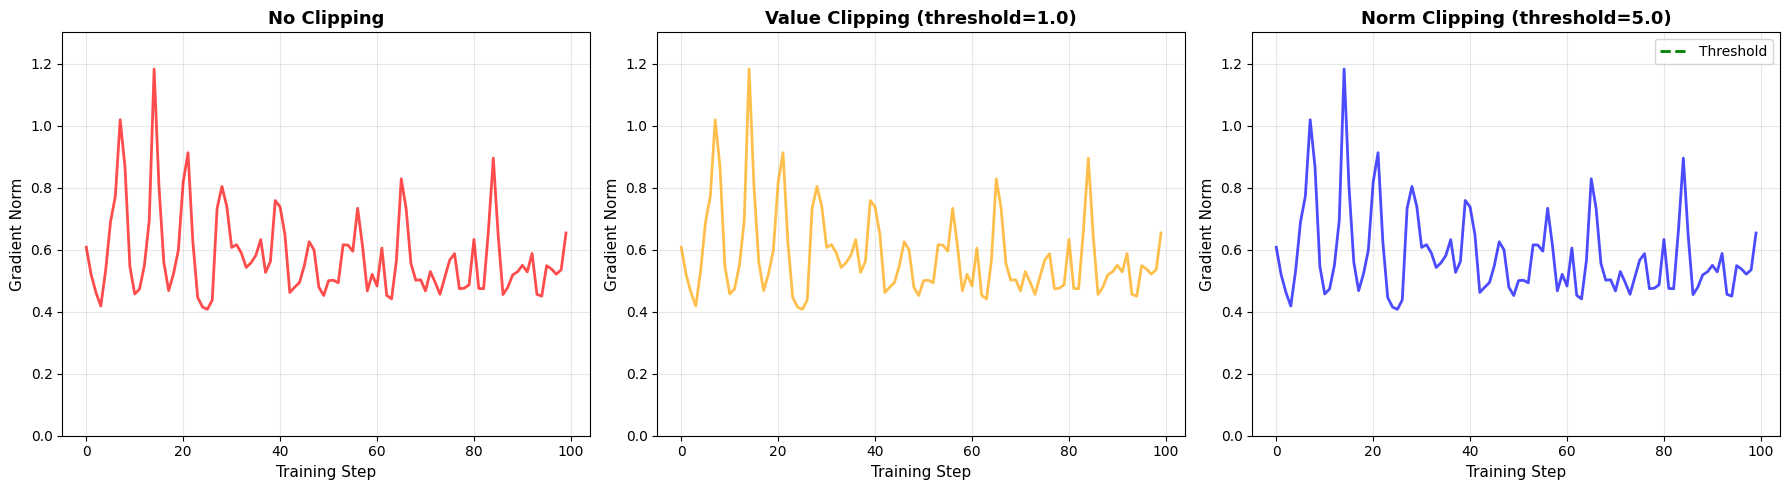


Comparison of all three approaches:

1. No clipping:
   - Max norm: 1.18
   - Mean norm: 0.58
   - Loss: 2.4687

2. Value clipping (threshold=1.0):
   - Max norm: 1.18
   - Mean norm: 0.58
   - Loss: 2.4687
   - Note: Norm is NOT bounded (only individual values are!)

3. Norm clipping (threshold=5.0):
   - Max norm: 1.18
   - Mean norm: 0.58
   - Loss: 2.4687
   - Note: Norm is strictly bounded!


In [15]:
# Compare all three approaches
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: No clipping
ax = axes[0]
ax.plot(grad_norms_no_clip, linewidth=2, color='red', alpha=0.7)
ax.set_xlabel('Training Step', fontsize=11)
ax.set_ylabel('Gradient Norm', fontsize=11)
ax.set_title('No Clipping', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(grad_norms_no_clip) * 1.1)

# Plot 2: Value clipping
ax = axes[1]
ax.plot(grad_norms_value, linewidth=2, color='orange', alpha=0.7)
ax.set_xlabel('Training Step', fontsize=11)
ax.set_ylabel('Gradient Norm', fontsize=11)
ax.set_title(f'Value Clipping (threshold={value_threshold})', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, max(grad_norms_no_clip) * 1.1)

# Plot 3: Norm clipping
ax = axes[2]
ax.plot(grad_norms_with_clip, linewidth=2, color='blue', alpha=0.7)
ax.axhline(y=clip_threshold, color='green', linestyle='--', linewidth=2, label='Threshold')
ax.set_xlabel('Training Step', fontsize=11)
ax.set_ylabel('Gradient Norm', fontsize=11)
ax.set_title(f'Norm Clipping (threshold={clip_threshold})', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0, max(grad_norms_no_clip) * 1.1)

plt.tight_layout()
plt.show()

print("\nComparison of all three approaches:")
print(f"\n1. No clipping:")
print(f"   - Max norm: {max(grad_norms_no_clip):.2f}")
print(f"   - Mean norm: {np.mean(grad_norms_no_clip):.2f}")
print(f"   - Loss: {train_loss:.4f}")

print(f"\n2. Value clipping (threshold={value_threshold}):")
print(f"   - Max norm: {max(grad_norms_value):.2f}")
print(f"   - Mean norm: {np.mean(grad_norms_value):.2f}")
print(f"   - Loss: {train_loss_value:.4f}")
print(f"   - Note: Norm is NOT bounded (only individual values are!)")

print(f"\n3. Norm clipping (threshold={clip_threshold}):")
print(f"   - Max norm: {max(grad_norms_with_clip):.2f}")
print(f"   - Mean norm: {np.mean(grad_norms_with_clip):.2f}")
print(f"   - Loss: {train_loss_clip:.4f}")
print(f"   - Note: Norm is strictly bounded!")

**Critical Insight:**

Notice that **value clipping does NOT bound the gradient norm!**

Why? Because value clipping acts element-wise:
- If you have 1000 parameters, each clipped to [-1, 1]
- The total gradient norm can still be up to √1000 ≈ 31.6
- Only the *individual elements* are bounded, not the *total magnitude*

This is why **norm clipping is usually preferred** - it gives you direct control over the gradient magnitude.

## Part 8: Choosing the Right Clipping Threshold

**Key Question:** How do you choose the clipping threshold?

**General approach:**
1. Monitor gradient norms during initial training (without clipping)
2. Look at the distribution of gradient norms
3. Choose a threshold that:
   - Prevents extreme outliers (99th percentile)
   - Doesn't clip too many gradients (you want most gradients to pass through)

**Common values:**
- RNNs: 1.0 - 5.0
- Transformers: 1.0
- Deep CNNs: 5.0 - 10.0

Let's experiment with different thresholds!

In [16]:
# Try multiple clipping thresholds
thresholds = [1.0, 2.0, 5.0, 10.0, 20.0]
results = {}

print("Testing different clipping thresholds...\n")

for threshold in thresholds:
    print(f"\nThreshold = {threshold}")
    print("-" * 40)
    
    # Reset model
    set_seed(42)
    model_test = SimpleRNN(vocab_size, embedding_dim=32, hidden_dim=64).to(device)
    optimizer_test = torch.optim.SGD(model_test.parameters(), lr=1.0)
    
    # Train
    loss, grad_norms = train_one_epoch(
        model_test, train_loader, optimizer_test, device,
        clip_norm=threshold, max_batches=max_batches
    )
    
    # Store results
    results[threshold] = {
        'loss': loss,
        'grad_norms': grad_norms,
        'max_norm': max(grad_norms),
        'mean_norm': np.mean(grad_norms),
        'clipped_pct': 100 * sum(1 for g in grad_norms if g > threshold - 0.01) / len(grad_norms)
    }
    
    print(f"  Loss: {loss:.4f}")
    print(f"  Max gradient norm: {max(grad_norms):.2f}")
    print(f"  % of gradients clipped: {results[threshold]['clipped_pct']:.1f}%")

print("\n" + "="*60)
print("Threshold sensitivity analysis complete!")
print("="*60)

Testing different clipping thresholds...


Threshold = 1.0
----------------------------------------


Training:   0%|          | 0/901 [00:00<?, ?it/s]

  Loss: 2.4689
  Max gradient norm: 1.16
  % of gradients clipped: 2.0%

Threshold = 2.0
----------------------------------------


Training:   0%|          | 0/901 [00:00<?, ?it/s]

  Loss: 2.4687
  Max gradient norm: 1.18
  % of gradients clipped: 0.0%

Threshold = 5.0
----------------------------------------


...

  Loss: 2.4687
  Max gradient norm: 1.18
  % of gradients clipped: 0.0%

Threshold = 10.0
----------------------------------------


Training:   0%|          | 0/901 [00:00<?, ?it/s]

  Loss: 2.4687
  Max gradient norm: 1.18
  % of gradients clipped: 0.0%

Threshold = 20.0
----------------------------------------


Training:   0%|          | 0/901 [00:00<?, ?it/s]

  Loss: 2.4687
  Max gradient norm: 1.18
  % of gradients clipped: 0.0%

Threshold sensitivity analysis complete!


Visualize the results with multiple plots for comparison.

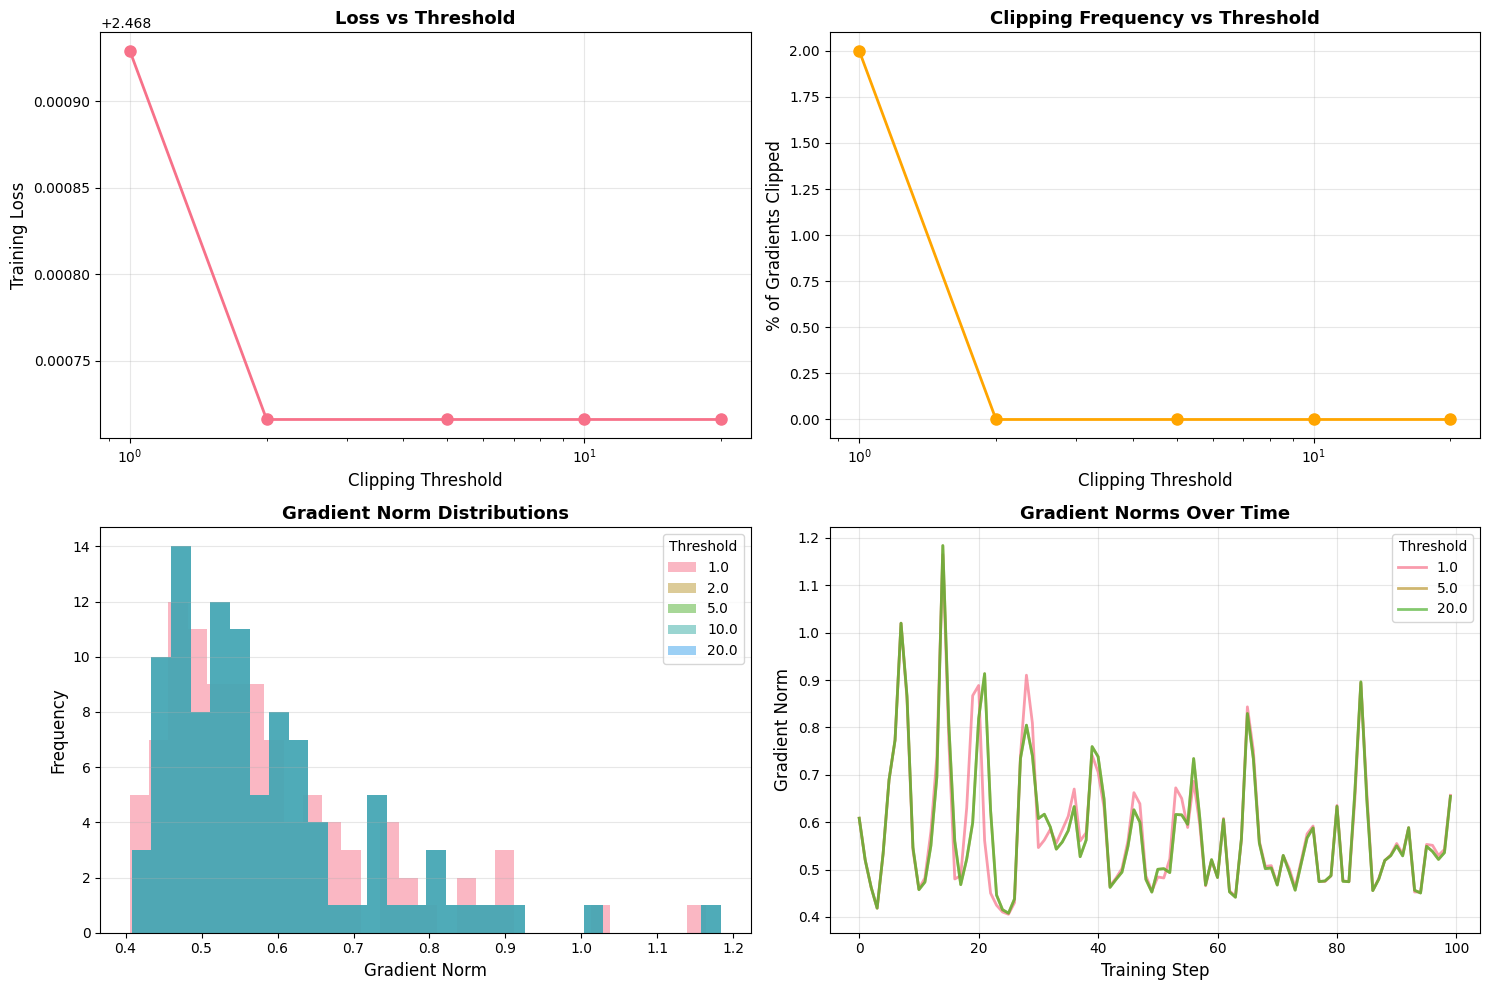


THRESHOLD SELECTION GUIDE

Rules of thumb:
1. Too small (e.g., 1.0): Clips too many gradients, slow learning
2. Too large (e.g., 20.0): Doesn't prevent extreme spikes
3. Just right (e.g., 5.0): Clips outliers, most gradients pass through

Recommendation: Choose threshold around 95th-99th percentile of gradient norms

For this model/task: ~0.8 (95th percentile)


In [17]:
# Visualize threshold sensitivity
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Training loss vs threshold
ax = axes[0, 0]
losses = [results[t]['loss'] for t in thresholds]
ax.plot(thresholds, losses, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Clipping Threshold', fontsize=12)
ax.set_ylabel('Training Loss', fontsize=12)
ax.set_title('Loss vs Threshold', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# Plot 2: % clipped vs threshold
ax = axes[0, 1]
clipped_pcts = [results[t]['clipped_pct'] for t in thresholds]
ax.plot(thresholds, clipped_pcts, 'o-', linewidth=2, markersize=8, color='orange')
ax.set_xlabel('Clipping Threshold', fontsize=12)
ax.set_ylabel('% of Gradients Clipped', fontsize=12)
ax.set_title('Clipping Frequency vs Threshold', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

# Plot 3: Gradient norm distributions
ax = axes[1, 0]
for threshold in thresholds:
    ax.hist(results[threshold]['grad_norms'], bins=30, alpha=0.5, label=f'{threshold}')
ax.set_xlabel('Gradient Norm', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Gradient Norm Distributions', fontsize=13, fontweight='bold')
ax.legend(title='Threshold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Gradient norms over time (selected thresholds)
ax = axes[1, 1]
selected_thresholds = [1.0, 5.0, 20.0]
for threshold in selected_thresholds:
    ax.plot(results[threshold]['grad_norms'], alpha=0.7, linewidth=2, label=f'{threshold}')
ax.set_xlabel('Training Step', fontsize=12)
ax.set_ylabel('Gradient Norm', fontsize=12)
ax.set_title('Gradient Norms Over Time', fontsize=13, fontweight='bold')
ax.legend(title='Threshold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print recommendations
print("\n" + "="*60)
print("THRESHOLD SELECTION GUIDE")
print("="*60)
print("\nRules of thumb:")
print("1. Too small (e.g., 1.0): Clips too many gradients, slow learning")
print("2. Too large (e.g., 20.0): Doesn't prevent extreme spikes")
print("3. Just right (e.g., 5.0): Clips outliers, most gradients pass through")
print("\nRecommendation: Choose threshold around 95th-99th percentile of gradient norms")

# Calculate recommended threshold from unclipped training
recommended = np.percentile(grad_norms_no_clip, 95)
print(f"\nFor this model/task: ~{recommended:.1f} (95th percentile)")

**Key Takeaways:**

1. **Too aggressive clipping (low threshold):**
   - Clips many gradients
   - Slows down learning
   - May prevent convergence

2. **Too lenient clipping (high threshold):**
   - Doesn't prevent extreme spikes
   - Unstable training
   - Similar to no clipping

3. **Sweet spot (moderate threshold):**
   - Clips only outliers (5-10% of gradients)
   - Stable training
   - Good convergence

**Practical advice:** Start with threshold around 5.0 for RNNs, adjust based on gradient norm monitoring.

## Part 9: When to Use Gradient Clipping

### ✅ USE gradient clipping when:

1. **Training RNNs/LSTMs/GRUs**
   - Recurrent connections amplify gradients
   - Long sequences make it worse
   - Almost always beneficial

2. **Training very deep networks**
   - Many layers = many gradient multiplications
   - Especially without batch norm

3. **Using high learning rates**
   - Large LR + large gradient = explosion
   - Clipping provides safety net

4. **Reinforcement learning**
   - Policy gradients can be unstable
   - Common practice in PPO, A3C, etc.

5. **Fine-tuning pre-trained models**
   - Prevents catastrophic forgetting from large updates
   - Especially important for language models

6. **When you observe:**
   - NaN or Inf losses
   - Sudden loss spikes
   - Extremely large gradient norms (>100)

### ❌ DON'T use gradient clipping when:

1. **Training shallow networks**
   - Not necessary for simple models
   - Adds unnecessary complexity

2. **Networks with batch normalization**
   - Batch norm already stabilizes gradients
   - Clipping may be redundant

3. **Well-tuned learning rate + optimizer**
   - Adam with default LR (0.001) is usually stable
   - If training is already stable, don't add clipping

4. **You have better alternatives:**
   - Poor weight initialization → Use He/Xavier init
   - Gradient vanishing → Use skip connections, better architecture
   - Unstable training → Try batch norm, layer norm, weight decay

5. **You're over-clipping:**
   - If >50% of gradients are being clipped
   - You're likely hurting learning
   - Increase threshold or fix root cause

### Decision Tree: Should I Use Gradient Clipping?

```
Are you training an RNN/LSTM/GRU?
├─ YES → Use gradient clipping (threshold ~1-5)
└─ NO
   |
   Are you seeing NaN losses or huge gradient norms?
   ├─ YES → Try clipping, but also investigate root cause
   └─ NO
      |
      Is your network very deep (>50 layers) without batch norm?
      ├─ YES → Consider clipping
      └─ NO → Probably don't need clipping
```

## Part 10: Pros and Cons Summary

### Advantages of Gradient Clipping

| Advantage | Explanation |
|-----------|-------------|
| **Prevents explosion** | Bounds gradient magnitude, preventing NaN/Inf |
| **Enables higher LR** | Can use larger learning rates safely |
| **Simple to implement** | One line of PyTorch code |
| **Minimal overhead** | Very cheap computation |
| **Widely applicable** | Works with any optimizer |
| **Stabilizes training** | More consistent loss curves |

### Disadvantages of Gradient Clipping

| Disadvantage | Explanation |
|--------------|-------------|
| **Biases gradient direction** | Changes the optimization trajectory |
| **Loses information** | Discards magnitude information from large gradients |
| **Hyperparameter tuning** | Need to choose threshold (trial and error) |
| **May slow convergence** | Too aggressive clipping slows learning |
| **Masks root problems** | Might hide bad architecture or initialization |
| **Not a cure-all** | Doesn't solve vanishing gradients or other issues |

## Part 11: Alternatives and Complementary Techniques

Gradient clipping is not the only solution to training instability. Here are alternatives:

### 1. Better Weight Initialization
- **Xavier/Glorot initialization**: For tanh/sigmoid activations
- **He initialization**: For ReLU activations
- Prevents gradients from exploding/vanishing from the start

### 2. Normalization Layers
- **Batch normalization**: Normalizes activations, stabilizes gradients
- **Layer normalization**: Better for RNNs/Transformers
- **Group normalization**: Batch-independent alternative

### 3. Architectural Improvements
- **Skip connections** (ResNet): Provides gradient highways
- **LSTM/GRU**: Built-in gradient flow management
- **Gradient highway networks**: Explicit gradient paths

### 4. Optimizer Choices
- **Adam/AdamW**: Adaptive learning rates reduce explosion risk
- **RMSprop**: Scales gradients by recent magnitudes
- **Gradient normalization**: Built into some optimizers

### 5. Learning Rate Strategies
- **Learning rate warmup**: Start with small LR, gradually increase
- **Learning rate scheduling**: Reduce LR when unstable
- **Cyclical learning rates**: Prevent getting stuck in sharp minima

### When to Combine Techniques

Often, the best approach uses **multiple techniques together**:

```python
# Example: Stable RNN training recipe
model = MyRNN(
    # 1. Use LSTM instead of vanilla RNN
    cell_type='lstm',
    # 2. Add layer normalization
    use_layer_norm=True
)

# 3. Use Adam optimizer (adaptive learning rates)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 4. Add gradient clipping as safety net
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

# 5. Use learning rate scheduling
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer)
```

This "defense in depth" approach is more robust than relying on any single technique.

## Part 12: Practical PyTorch Implementation Patterns

### Pattern 1: Basic Gradient Clipping

In [18]:
# Standard training loop with gradient clipping
def train_with_clipping_basic(model, dataloader, optimizer, clip_norm=1.0):
    model.train()
    
    for batch in dataloader:
        x, y = batch
        
        # Forward pass
        optimizer.zero_grad()
        output = model(x)
        loss = F.cross_entropy(output, y)
        
        # Backward pass
        loss.backward()
        
        # ⭐ Gradient clipping (THIS IS THE KEY LINE!)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        
        # Optimizer step
        optimizer.step()

print("Pattern 1: Basic gradient clipping")
print("✓ Always clip AFTER backward(), BEFORE optimizer.step()")

Pattern 1: Basic gradient clipping
✓ Always clip AFTER backward(), BEFORE optimizer.step()


### Pattern 2: Gradient Clipping with Monitoring

In [19]:
# Training loop with gradient monitoring and logging
def train_with_monitoring(model, dataloader, optimizer, clip_norm=1.0):
    model.train()
    gradient_norms = []
    
    for batch in dataloader:
        x, y = batch
        
        optimizer.zero_grad()
        output = model(x)
        loss = F.cross_entropy(output, y)
        loss.backward()
        
        # ⭐ Compute gradient norm BEFORE clipping
        total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
        gradient_norms.append(total_norm.item())
        
        optimizer.step()
    
    # Print statistics
    print(f"Gradient norms - Mean: {np.mean(gradient_norms):.2f}, "
          f"Max: {max(gradient_norms):.2f}, "
          f"% clipped: {100*sum(1 for g in gradient_norms if g > clip_norm)/len(gradient_norms):.1f}%")
    
    return gradient_norms

print("Pattern 2: Gradient clipping with monitoring")
print("✓ clip_grad_norm_() returns the total norm before clipping")
print("✓ Use this to track gradient statistics over time")

Pattern 2: Gradient clipping with monitoring
✓ clip_grad_norm_() returns the total norm before clipping
✓ Use this to track gradient statistics over time


### Pattern 3: Adaptive Gradient Clipping

In [20]:
# Adaptive gradient clipping based on recent gradient norms
class AdaptiveClipping:
    def __init__(self, percentile=95, window_size=100):
        self.percentile = percentile
        self.window_size = window_size
        self.gradient_history = []
    
    def get_threshold(self):
        if len(self.gradient_history) < 10:
            return float('inf')  # Don't clip initially
        return np.percentile(self.gradient_history[-self.window_size:], self.percentile)
    
    def clip_and_update(self, parameters):
        # Compute current norm
        total_norm = 0.0
        for p in parameters:
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = math.sqrt(total_norm)
        
        # Update history
        self.gradient_history.append(total_norm)
        
        # Get adaptive threshold
        threshold = self.get_threshold()
        
        # Clip
        torch.nn.utils.clip_grad_norm_(parameters, threshold)
        
        return total_norm, threshold

# Usage
adaptive_clipper = AdaptiveClipping(percentile=95)

# In training loop:
# loss.backward()
# norm, threshold = adaptive_clipper.clip_and_update(model.parameters())
# optimizer.step()

print("Pattern 3: Adaptive gradient clipping")
print("✓ Threshold adjusts based on recent gradient norms")
print("✓ No manual tuning required")
print("✓ Useful when gradient statistics change during training")

Pattern 3: Adaptive gradient clipping
✓ Threshold adjusts based on recent gradient norms
✓ No manual tuning required
✓ Useful when gradient statistics change during training


### Pattern 4: Per-Parameter Gradient Clipping

In [21]:
# Clip different parameter groups with different thresholds
def clip_by_parameter_group(model, thresholds):
    """
    Example:
    thresholds = {
        'embedding': 0.5,  # More conservative for embeddings
        'rnn': 1.0,        # Standard for RNN
        'fc': 5.0          # More lenient for output layer
    }
    """
    for name, param in model.named_parameters():
        if param.grad is None:
            continue
        
        # Determine threshold based on parameter name
        threshold = 1.0  # default
        for key, value in thresholds.items():
            if key in name:
                threshold = value
                break
        
        # Clip this parameter
        param.grad.data.clamp_(-threshold, threshold)

print("Pattern 4: Per-parameter gradient clipping")
print("✓ Different thresholds for different layers")
print("✓ Useful when some layers are more sensitive than others")
print("✓ Example: Clip embeddings more conservatively")

Pattern 4: Per-parameter gradient clipping
✓ Different thresholds for different layers
✓ Useful when some layers are more sensitive than others
✓ Example: Clip embeddings more conservatively


## Part 13: Common Mistakes and How to Avoid Them

### ❌ Mistake 1: Clipping in the wrong order

In [22]:
# WRONG: Clipping before backward()
def wrong_order_1():
    """DON'T DO THIS!"""
    loss.backward()
    optimizer.step()  # ❌ Optimizer step before clipping!
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Too late!

# WRONG: Clipping after optimizer.step()
def wrong_order_2():
    """DON'T DO THIS!"""
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # ❌ No gradients yet!
    loss.backward()
    optimizer.step()

# ✅ CORRECT: Clip after backward(), before step()
def correct_order():
    loss.backward()  # Compute gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # ✓ Clip gradients
    optimizer.step()  # Update parameters

print("Common Mistake #1: Wrong order of operations")
print("\n✓ ALWAYS: backward() → clip() → step()")
print("✓ Remember: You're clipping GRADIENTS, so they must exist!")

Common Mistake #1: Wrong order of operations

✓ ALWAYS: backward() → clip() → step()
✓ Remember: You're clipping GRADIENTS, so they must exist!


### ❌ Mistake 2: Clipping too aggressively

In [23]:
# Demonstration of over-clipping
print("Common Mistake #2: Over-clipping")
print("\nSymptoms:")
print("- Training converges very slowly")
print("- Most gradients are being clipped (>50%)")
print("- Loss plateaus early")
print("\nSolution:")
print("- Increase clipping threshold")
print("- Monitor what % of gradients are being clipped")
print("- Aim for 5-20% clipping rate")
print("\nExample:")
print(f"  If 90% of gradients are being clipped: threshold TOO LOW")
print(f"  If 2% of gradients are being clipped: threshold TOO HIGH")
print(f"  If 10% of gradients are being clipped: threshold JUST RIGHT ✓")

Common Mistake #2: Over-clipping

Symptoms:
- Training converges very slowly
- Most gradients are being clipped (>50%)
- Loss plateaus early

Solution:
- Increase clipping threshold
- Monitor what % of gradients are being clipped
- Aim for 5-20% clipping rate

Example:
  If 90% of gradients are being clipped: threshold TOO LOW
  If 2% of gradients are being clipped: threshold TOO HIGH
  If 10% of gradients are being clipped: threshold JUST RIGHT ✓


### ❌ Mistake 3: Using value clipping instead of norm clipping

In [24]:
# Why norm clipping is usually better
print("Common Mistake #3: Using value clipping by default")
print("\nValue clipping (clip_grad_value_):")
print("  ❌ Changes gradient direction")
print("  ❌ Doesn't bound total gradient magnitude")
print("  ✓ OK for some specific cases (element-wise bounds)")
print("\nNorm clipping (clip_grad_norm_):")
print("  ✓ Preserves gradient direction")
print("  ✓ Bounds total gradient magnitude")
print("  ✓ More principled and commonly used")
print("\nRecommendation: Use norm clipping unless you have a specific reason not to!")

Common Mistake #3: Using value clipping by default

Value clipping (clip_grad_value_):
  ❌ Changes gradient direction
  ❌ Doesn't bound total gradient magnitude
  ✓ OK for some specific cases (element-wise bounds)

Norm clipping (clip_grad_norm_):
  ✓ Preserves gradient direction
  ✓ Bounds total gradient magnitude
  ✓ More principled and commonly used

Recommendation: Use norm clipping unless you have a specific reason not to!


### ❌ Mistake 4: Not monitoring gradient norms

In [25]:
# Always monitor your gradients!
print("Common Mistake #4: Not monitoring gradients")
print("\nWhat to monitor:")
print("  ✓ Gradient norm (total magnitude)")
print("  ✓ % of gradients being clipped")
print("  ✓ Distribution of gradient norms")
print("  ✓ Per-layer gradient norms (for debugging)")
print("\nWhy monitor:")
print("  - Detect gradient explosion early")
print("  - Tune clipping threshold")
print("  - Understand training dynamics")
print("  - Diagnose convergence issues")
print("\nHow to monitor:")
print("  1. Use clip_grad_norm_() return value (pre-clipping norm)")
print("  2. Log to TensorBoard/W&B")
print("  3. Plot distributions periodically")

Common Mistake #4: Not monitoring gradients

What to monitor:
  ✓ Gradient norm (total magnitude)
  ✓ % of gradients being clipped
  ✓ Distribution of gradient norms
  ✓ Per-layer gradient norms (for debugging)

Why monitor:
  - Detect gradient explosion early
  - Tune clipping threshold
  - Understand training dynamics
  - Diagnose convergence issues

How to monitor:
  1. Use clip_grad_norm_() return value (pre-clipping norm)
  2. Log to TensorBoard/W&B
  3. Plot distributions periodically


## Part 14: Advanced Topics

### Topic 1: Gradient Clipping in Modern Optimizers

Some optimizers (like Adam) already do some form of gradient normalization. How does clipping interact?

**Adam + Gradient Clipping:**
- Adam normalizes gradients by their running average
- Clipping still helps prevent extreme updates
- Common in Transformer training (e.g., BERT uses clip_norm=1.0)

**Order of operations:**
```python
loss.backward()  # Compute raw gradients
clip_grad_norm_(...)  # Clip raw gradients
optimizer.step()  # Adam then normalizes the clipped gradients
```

**Key insight:** Clipping happens to raw gradients, optimizer normalization happens to clipped gradients.

### Topic 2: Gradient Clipping in Distributed Training

When training across multiple GPUs:

1. Gradients are computed locally on each GPU
2. Gradients are averaged across GPUs (allreduce)
3. **Then** clipping is applied to the averaged gradients

**Important:** Don't clip before averaging! The norm should be computed on the global gradient.

PyTorch DDP (DistributedDataParallel) handles this correctly by default.

### Topic 3: Gradient Accumulation + Clipping

When accumulating gradients over multiple batches:

```python
# WRONG: Clip every accumulation step
for i, batch in enumerate(dataloader):
    loss = model(batch)
    loss.backward()
    clip_grad_norm_(model.parameters(), 1.0)  # ❌ Clips partial gradients!
    
    if (i + 1) % accumulation_steps == 0:
        optimizer.step()
        optimizer.zero_grad()

# CORRECT: Clip only before optimizer step
for i, batch in enumerate(dataloader):
    loss = model(batch)
    loss.backward()
    
    if (i + 1) % accumulation_steps == 0:
        clip_grad_norm_(model.parameters(), 1.0)  # ✓ Clips accumulated gradients
        optimizer.step()
        optimizer.zero_grad()
```

**Key insight:** Always clip the final accumulated gradient, not intermediate ones!

## Part 15: Summary and Key Takeaways

### 🎯 Core Concepts

1. **Gradient Explosion**
   - Happens when gradients grow exponentially during backprop
   - Common in RNNs and very deep networks
   - Causes: repeated matrix multiplication, poor initialization, high LR

2. **Gradient Clipping Solutions**
   - **Value clipping**: Clips each gradient element independently
   - **Norm clipping**: Rescales entire gradient vector (better!)
   - Norm clipping preserves direction, value clipping does not

3. **Geometric Intuition**
   - Clipping creates a "sphere of acceptable gradients"
   - Norm clipping: circular boundary (preserves direction)
   - Value clipping: square boundary (can change direction)

4. **Choosing Threshold**
   - Monitor gradient norms during initial training
   - Choose threshold around 95th-99th percentile
   - Common values: 1.0-5.0 for RNNs, 1.0 for Transformers
   - Aim to clip 5-20% of gradients (not more!)

### ✅ When to Use Gradient Clipping

- Training RNNs/LSTMs/GRUs (almost always!)
- Very deep networks without batch norm
- High learning rates
- Reinforcement learning
- When observing NaN losses or gradient explosions

### ❌ When NOT to Use Gradient Clipping

- Shallow networks
- Networks with batch normalization (usually redundant)
- When training is already stable
- When better alternatives exist (initialization, architecture changes)

### 🛠️ PyTorch Implementation

```python
# Standard pattern (norm clipping)
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()

# With monitoring
loss.backward()
total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
print(f"Gradient norm: {total_norm:.2f}")
optimizer.step()
```

### 🎓 Key Insights

1. **Direction matters**: Norm clipping preserves gradient direction, value clipping doesn't
2. **Clipping is not a cure-all**: It treats symptoms, not root causes
3. **Monitor your gradients**: Always track gradient norms to tune threshold
4. **Combine techniques**: Best results come from multiple stabilization methods
5. **Threshold is critical**: Too low = slow learning, too high = explosions

### 🔬 Experimental Findings (From This Notebook)

- Without clipping: Gradient norms can spike to extreme values
- With clipping: Training becomes stable and predictable
- Norm clipping > value clipping for most use cases
- Optimal threshold depends on model, data, and learning rate
- Monitoring is essential for tuning

### 📚 Further Reading

- [On the difficulty of training RNNs](https://arxiv.org/abs/1211.5063) - Bengio et al.
- [PyTorch Gradient Clipping Documentation](https://pytorch.org/docs/stable/nn.html#clip-grad-norm)
- [Understanding LSTM Networks](http://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- [Gradient Descent Optimization Algorithms](https://ruder.io/optimizing-gradient-descent/)

## 🎯 Final Reflection Questions

1. **Why does gradient clipping by norm preserve the gradient direction while value clipping does not?**
   <details>
   <summary>Click to reveal answer</summary>
   Norm clipping rescales the entire gradient vector uniformly (multiplies all components by the same scalar), which preserves the direction. Value clipping clips each component independently, which can change the relative magnitudes and thus the direction.
   </details>

2. **If you're clipping 80% of your gradients, is your threshold too high or too low?**
   <details>
   <summary>Click to reveal answer</summary>
   Too low! You're clipping too many gradients, which will slow down learning. Increase the threshold to clip only outliers (aim for 5-20%).
   </details>

3. **Your loss suddenly becomes NaN. Gradient clipping should be applied (before/after) the backward pass?**
   <details>
   <summary>Click to reveal answer</summary>
   After! The correct order is: loss.backward() → clip gradients → optimizer.step(). You need gradients to exist before you can clip them.
   </details>

4. **Why is gradient clipping particularly important for RNNs?**
   <details>
   <summary>Click to reveal answer</summary>
   RNNs repeatedly multiply gradients by the recurrent weight matrix at each timestep during backpropagation through time (BPTT). If the largest eigenvalue of this matrix is > 1, gradients grow exponentially with sequence length.
   </details>

5. **Can gradient clipping solve the vanishing gradient problem?**
   <details>
   <summary>Click to reveal answer</summary>
   No! Gradient clipping only helps with exploding gradients (too large). For vanishing gradients (too small), you need different solutions like LSTM/GRU, skip connections, or better initialization.
   </details>

## 🚀 Next Steps: Try This!

1. **Experiment with your own models:**
   - Add gradient clipping to your current projects
   - Monitor gradient norms and tune thresholds
   - Compare training stability with/without clipping

2. **Advanced experiments:**
   - Implement adaptive clipping that adjusts threshold dynamically
   - Try per-layer clipping with different thresholds
   - Compare gradient clipping with other stabilization techniques

3. **Read the research:**
   - Understand why modern transformers use clip_norm=1.0
   - Learn about gradient clipping in RL (PPO, A3C)
   - Explore alternatives like gradient normalization

**Congratulations!** You now have deep intuitions about gradient clipping. You understand:
- How it works mathematically and geometrically
- When to use it and when not to
- How to implement it correctly
- How to tune the threshold
- The pros, cons, and alternatives

Go forth and train stable neural networks! 🎉